In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
from libpysal import weights
import pandas as pd

In [8]:
caminho_arquivo = "..\\data\\raw\\shape_muni.gpkg"

Carregando o mapa...
Gerando o grafo de vizinhança


C:\Users\segun\AppData\Local\Temp\ipykernel_34060\2853205402.py:7: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = weights.contiguity.Queen.from_dataframe(gdf_muni)
c:\Users\segun\AppData\Local\pypoetry\Cache\virtualenvs\dl-master-d400um7a-py3.12\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
 There are 2 islands with ids: 1525, 3499.
  W.__init__(self, neighbors, ids=ids, **kw)
C:\Users\segun\AppData\Local\Temp\ipykernel_34060\2853205402.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  positions = dict(zip(G.nodes, gdf_muni.geometry.centroid.apply(lambda p: (p.x, p.y))))


Calculando centroides para o plot...
Plotando...
Concluído.


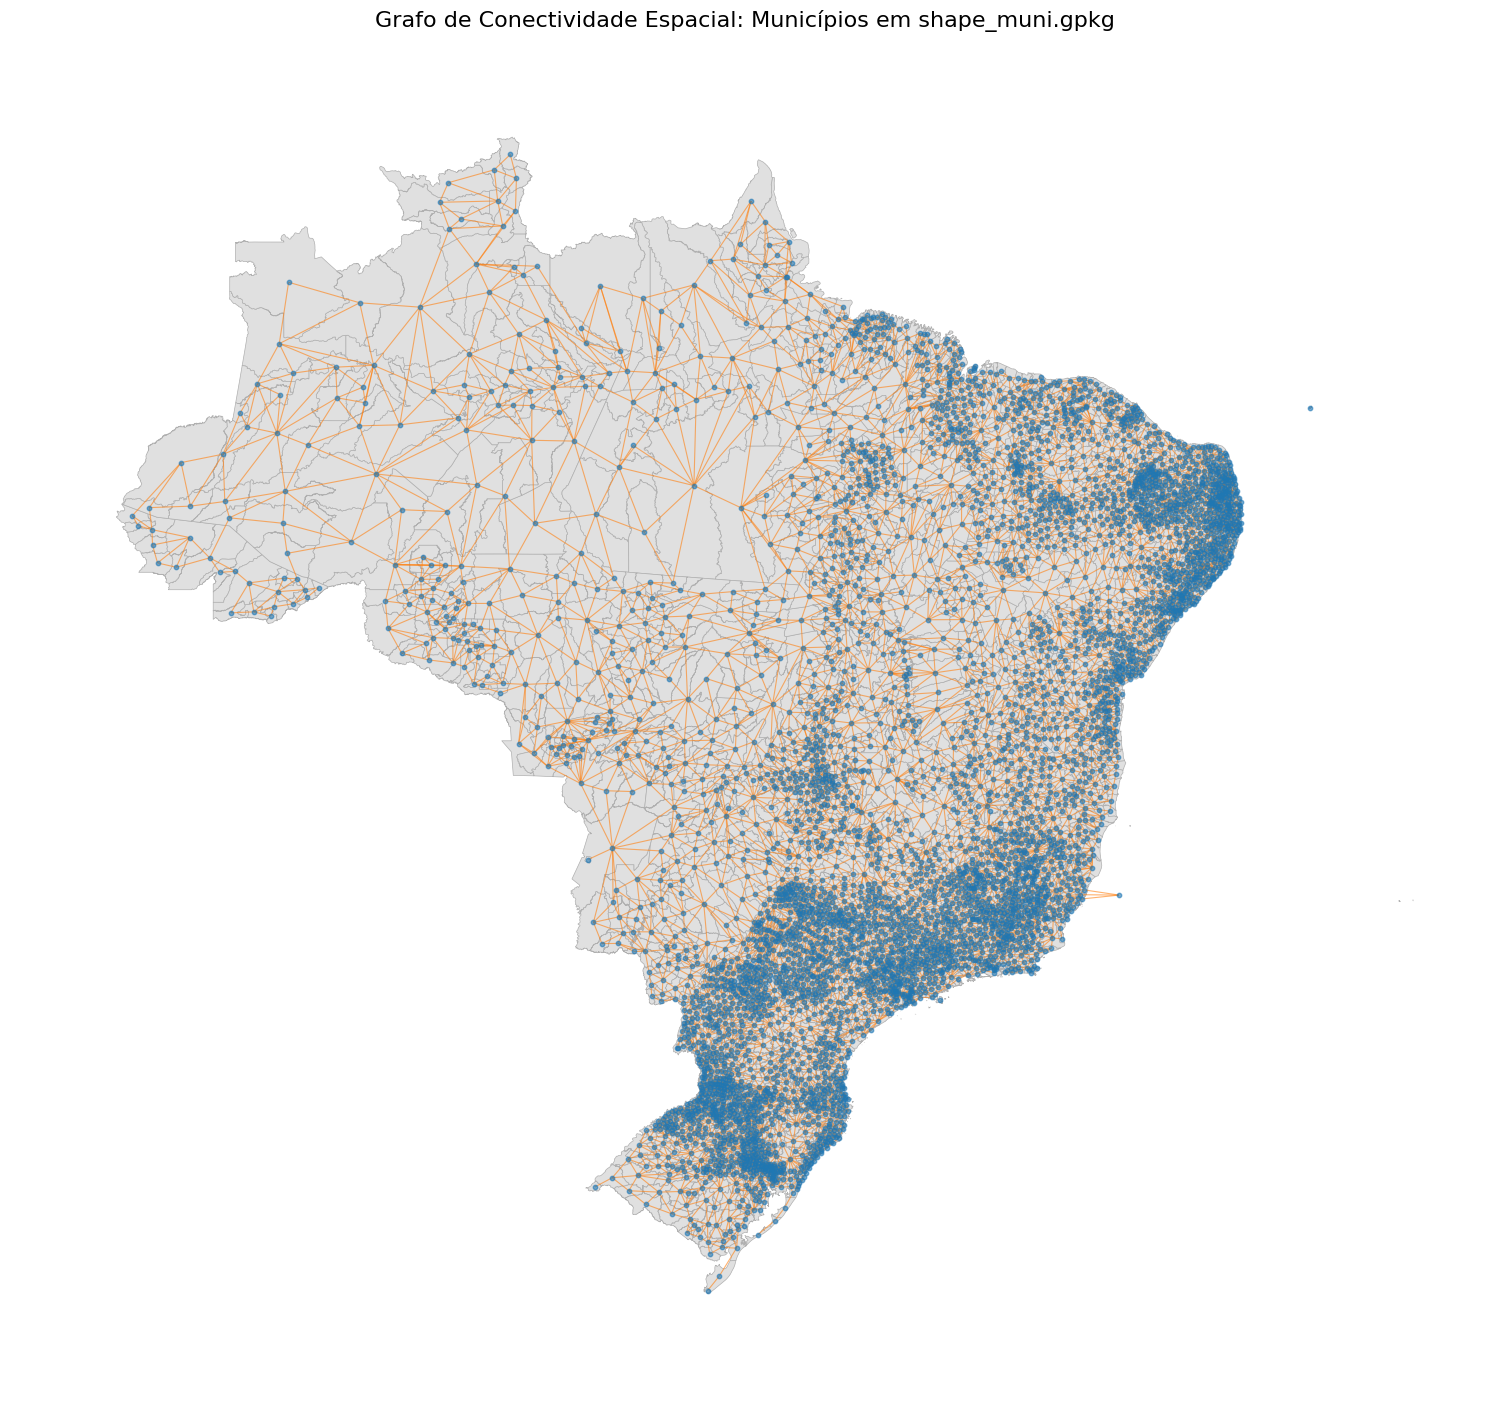

In [9]:
print("Carregando o mapa...")
gdf_muni = gpd.read_file(caminho_arquivo)

gdf_muni = gdf_muni.reset_index(drop=True)

print("Gerando o grafo de vizinhança")
w = weights.contiguity.Queen.from_dataframe(gdf_muni)

G = w.to_networkx()

print("Calculando centroides para o plot...")
positions = dict(zip(G.nodes, gdf_muni.geometry.centroid.apply(lambda p: (p.x, p.y))))

print("Plotando...")
fig, ax = plt.subplots(figsize=(15, 15)) # Tamanho grande para ver detalhes

gdf_muni.plot(
    ax=ax, 
    color='#e0e0e0',   
    edgecolor='#b0b0b0', 
    linewidth=0.5
)


nx.draw(
    G, 
    pos=positions, 
    ax=ax, 
    node_size=10,        
    node_color='#1f77b4', 
    edge_color='#ff7f0e',
    width=0.8,          
    alpha=0.6           
)

plt.title("Grafo de Conectividade Espacial: Municípios em shape_muni.gpkg", fontsize=16)
plt.axis("off") 
plt.tight_layout()

print("Concluído.")
plt.show()

In [11]:
print("Iniciando extração de métricas do grafo...")

eigen_cent = nx.eigenvector_centrality(G, max_iter=1000)
clustering_coeff = nx.clustering(G)
degree_cent = dict(G.degree())
pagerank = nx.pagerank(G)

df_metrics = pd.DataFrame({
    'node_idx': list(G.nodes),
    'eigen_centrality': [eigen_cent[i] for i in G.nodes],
    'clustering_coeff': [clustering_coeff[i] for i in G.nodes],
    'degree_connectivity': [degree_cent[i] for i in G.nodes],
    'pagerank_score': [pagerank[i] for i in G.nodes]
})

df_metrics['geocode'] = gdf_muni.loc[df_metrics['node_idx'], 'geocode'].values

df_static_spatial = df_metrics.drop(columns=['node_idx'])

print("Métricas calculadas com sucesso.")
print(df_static_spatial.head())

Iniciando extração de métricas do grafo...
Métricas calculadas com sucesso.
   eigen_centrality  clustering_coeff  degree_connectivity  pagerank_score  \
0          0.000001          0.285714                    7        0.000235   
1          0.000001          0.285714                    7        0.000215   
2          0.000005          0.000000                    2        0.000087   
3          0.000005          0.238095                    7        0.000230   
4          0.000002          0.666667                    3        0.000125   

   geocode  
0  1100015  
1  1100023  
2  1100031  
3  1100049  
4  1100056  


In [14]:
df_static_spatial.to_parquet("../data/processed/metrics_static_spatial.parquet", index=False)

print("Métricas estáticas salvas em Parquet.")

for i, node in enumerate(G.nodes()):
    G.nodes[node]['geocode'] = str(gdf_muni.loc[node, 'geocode'])

nx.write_graphml(G, "../data/processed/grafo_municipios.graphml")

print("Grafo salvo em GraphML.")

Métricas estáticas salvas em Parquet.
Grafo salvo em GraphML.
